# SEEG Manifold Analysis — Quick Start

This notebook runs the full toolkit end to end on **synthetic data with a known
ground truth**, so every number below can be checked against the value it should
recover. No external data is required.

Contents:

1. Generate synthetic SEEG with a known number of latent sources
2. Preprocess (filter, re-reference, epoch)
3. Estimate intrinsic dimensionality — does it recover the true value?
4. Compare dimensionality reduction methods
5. Test for rotational symmetry, with a permutation test and a negative control

Runtime: about 1-2 minutes on a laptop CPU.

## Setup

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '..')

# UMAP warns that fixing random_state disables its parallelism. That is the
# intended trade-off here: reproducible output matters more than speed.
warnings.filterwarnings('ignore', message='n_jobs value .* overridden')

from seeg_manifold.io import SEEGData
from seeg_manifold.preprocessing import preprocess_pipeline
from seeg_manifold.preprocessing.epoching import concatenate_epochs
from seeg_manifold.manifold import estimate_dimensionality, compare_reductions, fit_pca
from seeg_manifold.symmetry import detect_rotational_symmetry

rng = np.random.default_rng(42)
plt.rcParams['figure.dpi'] = 110

## 1. Synthetic SEEG data

We mix `n_sources = 5` oscillatory latent sources into 32 channels through a
random mixing matrix, then add independent per-channel noise. The signal
subspace is therefore exactly 5-dimensional — that is the number the
dimensionality estimators should recover in step 3.

In [2]:
sfreq = 500.0          # Hz
duration = 60.0        # seconds
n_channels = 32
n_sources = 5          # <-- ground truth
noise_level = 0.2

n_times = int(sfreq * duration)
t = np.arange(n_times) / sfreq

# Latent oscillatory sources (frequency, phase)
source_params = [(10, 0.0), (6, 0.7), (21, 1.3), (10, np.pi / 4), (38, 2.1)]
sources = np.vstack([np.sin(2 * np.pi * f * t + p) for f, p in source_params])

mixing = rng.normal(size=(n_channels, n_sources))       # volume conduction
raw = mixing @ sources + noise_level * rng.normal(size=(n_channels, n_times))

data = SEEGData(data=raw, sfreq=sfreq,
                ch_names=[f'sEEG{i + 1}' for i in range(n_channels)])
print(data)
print(f"True latent dimensionality: {n_sources}")

SEEGData(32 channels, 30000 timepoints) @ 500.0Hz, duration=60.00s
True latent dimensionality: 5


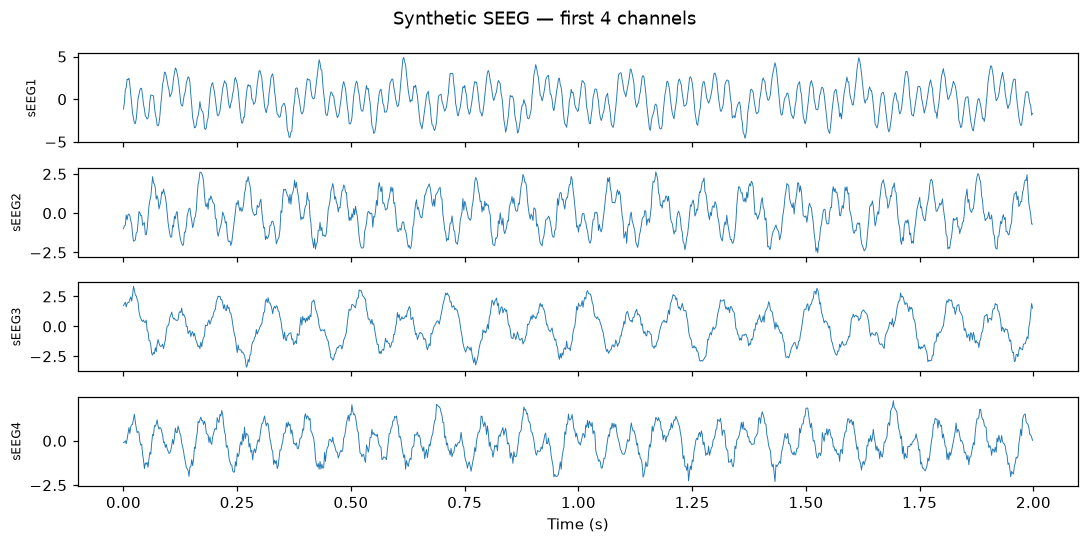

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(10, 5), sharex=True)
window = int(2 * sfreq)
for i, ax in enumerate(axes):
    ax.plot(t[:window], data.data[i, :window], lw=0.6)
    ax.set_ylabel(data.ch_names[i], fontsize=8)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Synthetic SEEG — first 4 channels')
fig.tight_layout()
plt.show()

## 2. Preprocessing

Band-pass filter, common average reference, then split into overlapping epochs.
Epoch rejection uses a median/MAD criterion, so clean data passes through
untouched while genuine amplitude outliers are removed.

In [4]:
processed, info = preprocess_pipeline(
    data.data, sfreq=data.sfreq,
    lowcut=1, highcut=100,
    notch_freq=None,          # synthetic data has no line noise
    epoch_length=2.0, epoch_overlap=0.5,
    verbose=True,
)
print(f"\nEpochs kept: {info['epoching']['n_epochs_final']} / "
      f"{info['epoching']['n_epochs_original']}")
print(f"Processed shape: {processed.shape}  (epochs, channels, timepoints)")

[1/4] Filtering: 1-100 Hz, notch=50.0 Hz
[2/4] Applying common average reference
[3/4] Artifact removal: threshold
[4/4] Epoching: 2.0s epochs, 50% overlap

Done! Output shape: (57, 32, 1000)

Epochs kept: 57 / 59
Processed shape: (57, 32, 1000)  (epochs, channels, timepoints)


## 3. Intrinsic dimensionality

**Orientation matters.** The estimators expect `(n_samples, n_features)`. Here
the samples are *timepoints* and the features are *channels*, so we concatenate
the epochs back to a continuous array and transpose. Feeding in
`(n_epochs, n_channels x n_timepoints)` instead would ask the estimators to work
with 57 samples in ~100,000 dimensions, which recovers nothing.

In [5]:
continuous = concatenate_epochs(processed)      # (n_channels, n_samples)
samples = continuous.T                          # (n_samples, n_channels)

# Subsample for the neighbour-based estimator
idx = rng.choice(len(samples), size=4000, replace=False)
subset = samples[idx]
print(f"Estimating on {subset.shape[0]} timepoints x {subset.shape[1]} channels")

dim_results = estimate_dimensionality(
    subset, methods=['pca_variance', 'pca_elbow', 'mle'],
    variance_threshold=0.95, verbose=True,
)
print(f"\nTrue latent dimensionality: {n_sources}")
print(f"Consensus estimate:         {dim_results['consensus']}")

Estimating on 4000 timepoints x 32 channels
Estimating dimensionality for data shape: (4000, 32)
  PCA (95% variance): 5 dimensions
  PCA (elbow): 6 dimensions


  MLE: 4.3 dimensions
  Consensus (median): 5 dimensions

True latent dimensionality: 5
Consensus estimate:         5


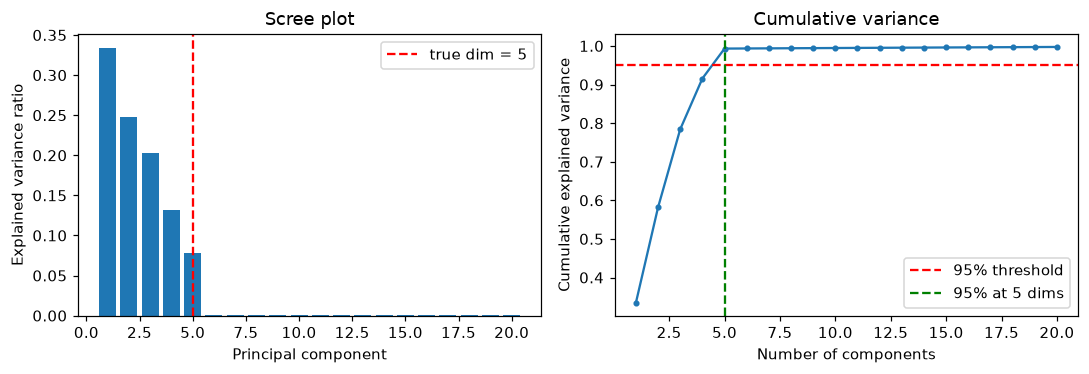

In [6]:
var_ratio = dim_results['pca_variance_ratio']
cumvar = np.cumsum(var_ratio)
n_show = min(20, len(var_ratio))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(range(1, n_show + 1), var_ratio[:n_show])
axes[0].axvline(n_sources, color='r', ls='--', label=f'true dim = {n_sources}')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Scree plot')
axes[0].legend()

axes[1].plot(range(1, n_show + 1), cumvar[:n_show], 'o-', ms=3)
axes[1].axhline(0.95, color='r', ls='--', label='95% threshold')
axes[1].axvline(dim_results['pca_variance'], color='g', ls='--',
                label=f"95% at {dim_results['pca_variance']} dims")
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('Cumulative variance')
axes[1].legend()
fig.tight_layout()
plt.show()

## 4. Comparing dimensionality reduction methods

Each method embeds the same data into 3 dimensions. `distance_correlation` is
the Spearman correlation between pairwise distances before and after embedding —
higher means the global geometry is better preserved. Local methods such as
t-SNE deliberately sacrifice global distances, so a low value there is expected
rather than a failure.

In [7]:
idx_small = rng.choice(len(samples), size=1500, replace=False)
subset_small = samples[idx_small]

reduction_results = compare_reductions(
    subset_small, methods=['pca', 'umap', 'tsne', 'isomap'],
    n_components=3, compute_metrics=True, verbose=True,
)

Computing original pairwise distances...
Fitting PCA...


  Distance correlation: 0.916
Fitting UMAP...


  Distance correlation: 0.476
Fitting TSNE...


  Distance correlation: 0.562
Fitting ISOMAP...


  Distance correlation: 0.544

Comparison complete!

Distance preservation (Spearman correlation):
  pca: 0.916
  umap: 0.476
  tsne: 0.562
  isomap: 0.544


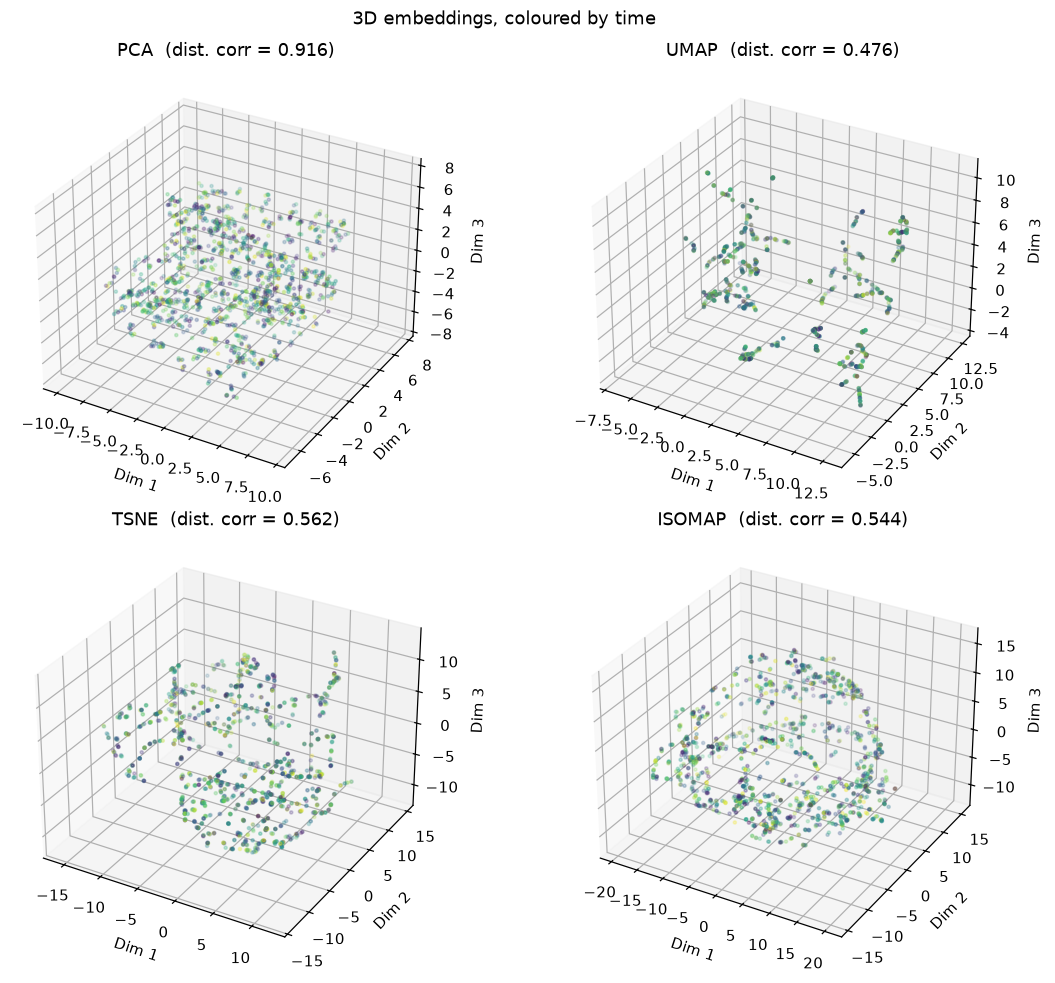

In [8]:
methods = list(reduction_results)
fig = plt.figure(figsize=(11, 9))
colour = idx_small  # colour by time
for i, method in enumerate(methods):
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    emb = reduction_results[method].embedding
    ax.scatter(emb[:, 0], emb[:, 1], emb[:, 2], c=colour, cmap='viridis', s=4, alpha=0.6)
    corr = reduction_results[method].metrics.get('distance_correlation')
    ax.set_title(f"{method.upper()}  (dist. corr = {corr:.3f})")
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2'); ax.set_zlabel('Dim 3')
fig.suptitle('3D embeddings, coloured by time', y=0.98)
fig.tight_layout()
plt.show()

## 5. Rotational symmetry, with a null model

A rotational symmetry detector that only reports "the strongest harmonic" will
always name some fold, even for unstructured data. `detect_rotational_symmetry`
therefore compares the observed harmonic power against surrogates drawn from a
uniform angular distribution and returns a permutation p-value, Bonferroni
corrected across the folds tested.

To show both directions we build two datasets:

- **structured**: 6 conditions whose mean patterns sit at 6 evenly spaced angles
  in a 2D coding plane embedded in channel space (6-fold symmetry by construction)
- **control**: the same trial count and noise, but no condition structure at all

The detector should find 6-fold symmetry in the first and nothing in the second.

In [9]:
n_cond, n_trials, trial_noise = 6, 60, 0.3

basis = np.linalg.qr(rng.normal(size=(n_channels, 2)))[0]   # 2D coding plane
angles = np.arange(n_cond) * 2 * np.pi / n_cond
centers = (basis @ np.c_[np.cos(angles), np.sin(angles)].T).T

labels = np.repeat(np.arange(n_cond), n_trials)
structured = centers[labels] + trial_noise * rng.normal(size=(len(labels), n_channels))
control = trial_noise * rng.normal(size=(len(labels), n_channels))

datasets = {'structured (6 conditions)': structured, 'control (no structure)': control}
embeddings, sym_results = {}, {}
for name, X in datasets.items():
    embeddings[name] = fit_pca(X, n_components=2)
    sym_results[name] = detect_rotational_symmetry(
        embeddings[name], n_permutations=1000, random_state=0
    )
    r = sym_results[name]
    print(f"{name:26s} best_fold={r['best_fold']}  score={r['best_score']:.4f}  "
          f"p={r['best_p_value']:.4f}  significant={r['significant']}")

structured (6 conditions)  best_fold=6  score=0.0567  p=0.0070  significant=True
control (no structure)     best_fold=8  score=0.0038  p=1.0000  significant=False


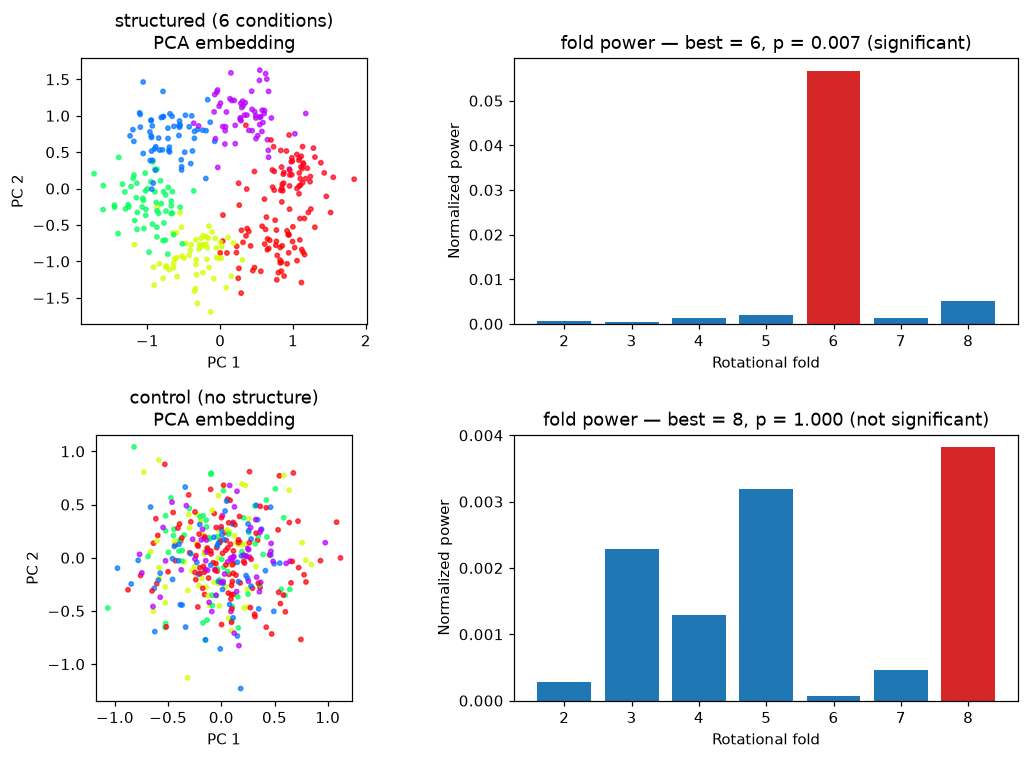

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for row, (name, emb) in enumerate(embeddings.items()):
    r = sym_results[name]
    ax = axes[row, 0]
    ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap='hsv', s=8, alpha=0.7)
    ax.set_aspect('equal')
    ax.set_title(f'{name}\nPCA embedding')
    ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')

    ax = axes[row, 1]
    folds = sorted(r['normalized_scores'])
    ax.bar(folds, [r['normalized_scores'][f] for f in folds],
           color=['tab:red' if f == r['best_fold'] else 'tab:blue' for f in folds])
    verdict = 'significant' if r['significant'] else 'not significant'
    ax.set_title(f"fold power — best = {r['best_fold']}, "
                 f"p = {r['best_p_value']:.3f} ({verdict})")
    ax.set_xlabel('Rotational fold'); ax.set_ylabel('Normalized power')
fig.tight_layout()
plt.show()

## Summary

On this synthetic dataset the toolkit:

- recovered the true latent dimensionality (5) from 32 mixed channels
- embedded the data with four reduction methods and quantified how well each
  preserved the original geometry
- detected 6-fold rotational symmetry where it was built in, and correctly
  reported *no* symmetry for the matched control

The symmetry p-values are the reason the last point is meaningful: without a
null model the detector would have reported a fold for the control too.

### Using your own data

```python
from seeg_manifold.io import load_seeg_data

data = load_seeg_data('my_recording.mat')   # also .edf, .fif
processed, info = preprocess_pipeline(data.data, sfreq=data.sfreq)
```

See the README for the expected MATLAB export format. Note that real recordings
need a notch filter (`notch_freq=50` or `60`), which is disabled above because
the synthetic data contains no line noise.